In [1]:
#importing all packages for training

In [2]:
import matplotlib.pyplot as plt

In [3]:
import numpy as np

In [4]:
import pandas as pd

In [5]:
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.linear_model import LogisticRegression

In [8]:
from sklearn.metrics import accuracy_score , confusion_matrix

In [9]:
#importing data set

In [10]:
data_set = pd.read_csv(r"C:\Users\mishr\Downloads\income(1).csv")

In [11]:
data = data_set.copy()

In [12]:
#EDA: handle NAN and missing values

In [13]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31978 entries, 0 to 31977
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   age            31978 non-null  int64 
 1   JobType        31978 non-null  object
 2   EdType         31978 non-null  object
 3   maritalstatus  31978 non-null  object
 4   occupation     31978 non-null  object
 5   relationship   31978 non-null  object
 6   race           31978 non-null  object
 7   gender         31978 non-null  object
 8   capitalgain    31978 non-null  int64 
 9   capitalloss    31978 non-null  int64 
 10  hoursperweek   31978 non-null  int64 
 11  nativecountry  31978 non-null  object
 12  SalStat        31978 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB
None


In [14]:
summary_nums = data.describe()

In [15]:
summary_cate = data.describe(include = "O")

In [16]:
print(summary_nums , summary_cate)

                age   capitalgain   capitalloss  hoursperweek
count  31978.000000  31978.000000  31978.000000  31978.000000
mean      38.579023   1064.360623     86.739352     40.417850
std       13.662085   7298.596271    401.594301     12.345285
min       17.000000      0.000000      0.000000      1.000000
25%       28.000000      0.000000      0.000000     40.000000
50%       37.000000      0.000000      0.000000     40.000000
75%       48.000000      0.000000      0.000000     45.000000
max       90.000000  99999.000000   4356.000000     99.000000          JobType    EdType        maritalstatus       occupation relationship  \
count      31978     31978                31978            31978        31978   
unique         9        16                    7               15            6   
top      Private   HS-grad   Married-civ-spouse   Prof-specialty      Husband   
freq       22286     10368                14692             4038        12947   

          race gender   nativecountr

In [17]:
print(data.isnull().sum()) #no missing values in data

age              0
JobType          0
EdType           0
maritalstatus    0
occupation       0
relationship     0
race             0
gender           0
capitalgain      0
capitalloss      0
hoursperweek     0
nativecountry    0
SalStat          0
dtype: int64


In [18]:
#handling NAN

In [19]:
data['JobType'].value_counts

<bound method IndexOpsMixin.value_counts of 0             Private
1         Federal-gov
2             Private
3             Private
4             Private
             ...     
31973       Local-gov
31974       Local-gov
31975         Private
31976       Local-gov
31977         Private
Name: JobType, Length: 31978, dtype: object>

In [20]:
print(np.unique(data['JobType']))

[' ?' ' Federal-gov' ' Local-gov' ' Never-worked' ' Private'
 ' Self-emp-inc' ' Self-emp-not-inc' ' State-gov' ' Without-pay']


In [21]:
data = pd.read_csv(r"C:\Users\mishr\Downloads\income(1).csv" , na_values = [' ?'])

In [22]:
#data preprocessing

In [23]:
print(data.isnull().sum())

age                 0
JobType          1809
EdType              0
maritalstatus       0
occupation       1816
relationship        0
race                0
gender              0
capitalgain         0
capitalloss         0
hoursperweek        0
nativecountry       0
SalStat             0
dtype: int64


In [24]:
missing = data[data.isnull().any(axis=1)]

In [25]:
#jobtype = 1809 and occupation = 1816 , 7 values more of occupation are missing beacuse the jobtype is "never worked"

In [26]:
#in this particular case we are going to remove all the rows which have nan value and "never worked" because it will not contribute to the pridiction variable

In [27]:
data2 = data.dropna(axis = 0)

In [28]:
# finding correlation between varibales

In [29]:
correlation = data2.select_dtypes(include=['number']).corr()

In [30]:
print(correlation)

                   age  capitalgain  capitalloss  hoursperweek
age           1.000000     0.080154     0.060165      0.101599
capitalgain   0.080154     1.000000    -0.032229      0.080432
capitalloss   0.060165    -0.032229     1.000000      0.052417
hoursperweek  0.101599     0.080432     0.052417      1.000000


In [31]:
#since no value is near to 1 , we not no relationship between variables

In [32]:
#cross tables and visualizations

In [33]:
gender_salstats = pd.crosstab(index = data2['gender'] , columns = data2['SalStat'] , margins = True , normalize = "index")

In [34]:
print(gender_salstats)

SalStat  greater than 50,000  less than or equal to 50,000
gender                                                    
 Female             0.113678                      0.886322
 Male               0.313837                      0.686163
All                 0.248922                      0.751078


<Axes: xlabel='count', ylabel='SalStat'>

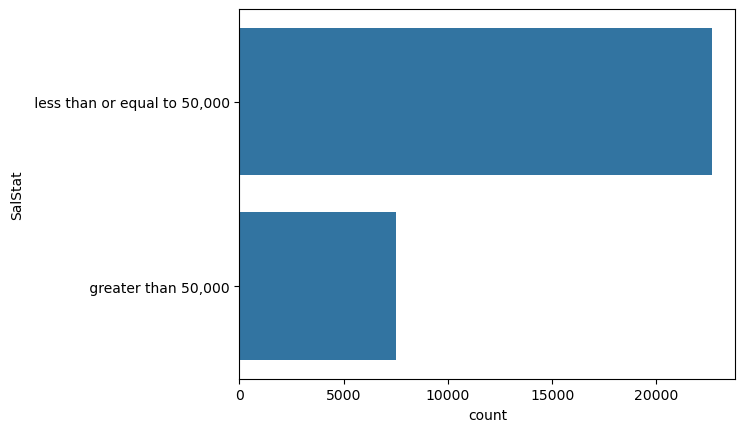

In [35]:
sns.countplot(data2['SalStat'])

In [36]:
#75% have <= 50,000 salary

<Axes: xlabel='age', ylabel='Count'>

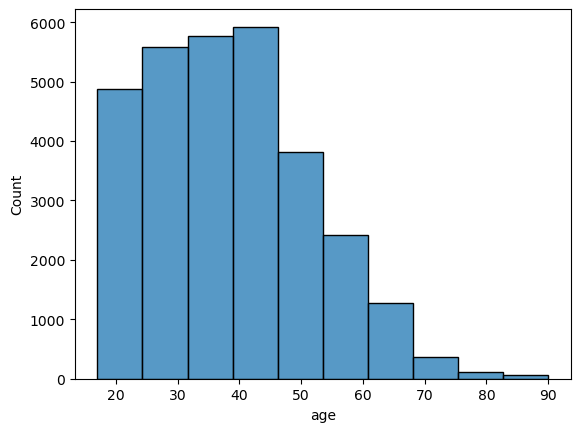

In [37]:
sns.histplot(data2['age'] , kde = False , bins = 10)

<Axes: xlabel='SalStat', ylabel='age'>

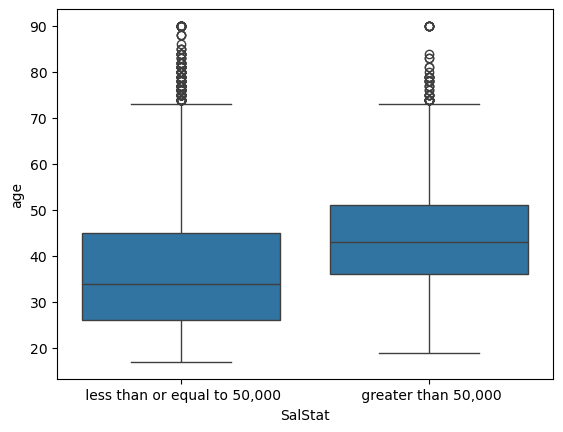

In [38]:
sns.boxplot(x='SalStat',y='age', data=data2)

In [39]:
data2.groupby('SalStat')['age'].median()

SalStat
greater than 50,000             43.0
less than or equal to 50,000    34.0
Name: age, dtype: float64

In [40]:
#interpretation: people with age 35-50 are more likely to earn more than 50,000 

In [41]:
#more EDA on dataset:-

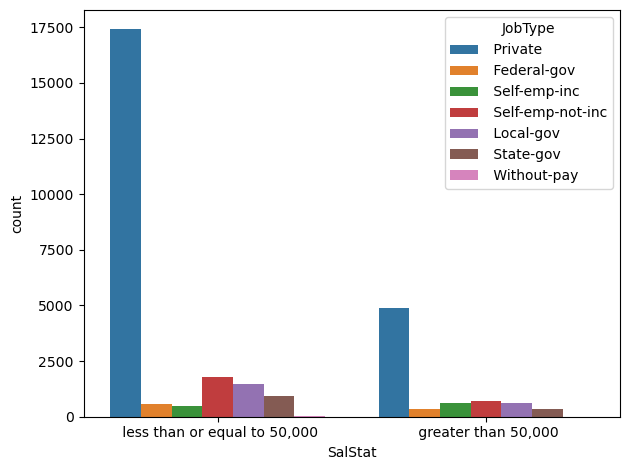

In [42]:
sns.countplot(x='SalStat', hue='JobType', data=data2)
plt.tight_layout() 


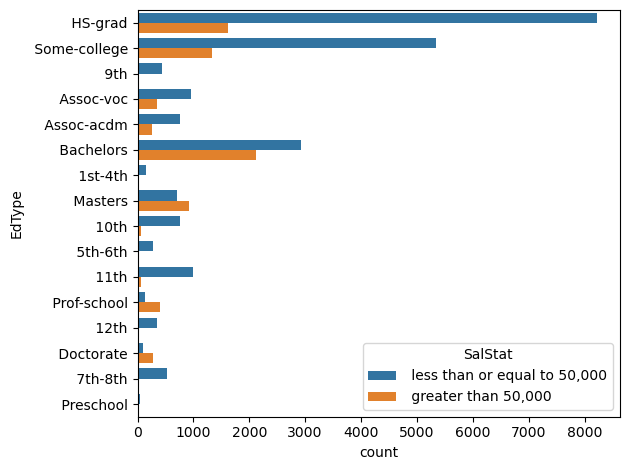

In [43]:
sns.countplot(y='EdType', hue='SalStat', data=data2)

plt.tight_layout()

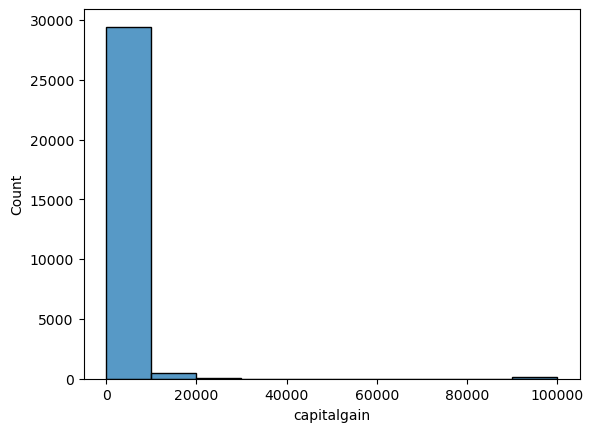

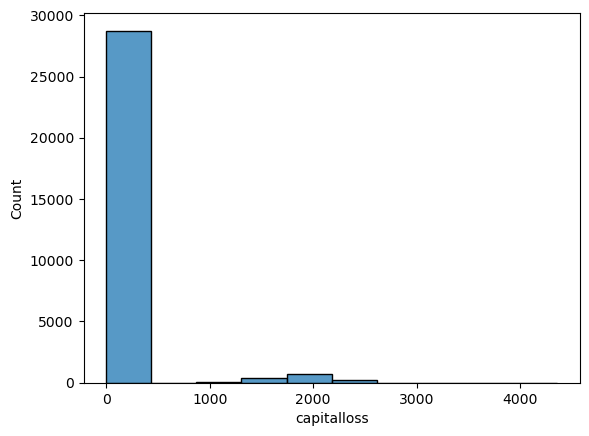

In [44]:
sns.histplot(data2['capitalgain'], bins=10)
plt.show()

sns.histplot(data2['capitalloss'], bins=10)
plt.show()

In [45]:
#92% of the capital gain id 0 and 95% of the capital loss is 0

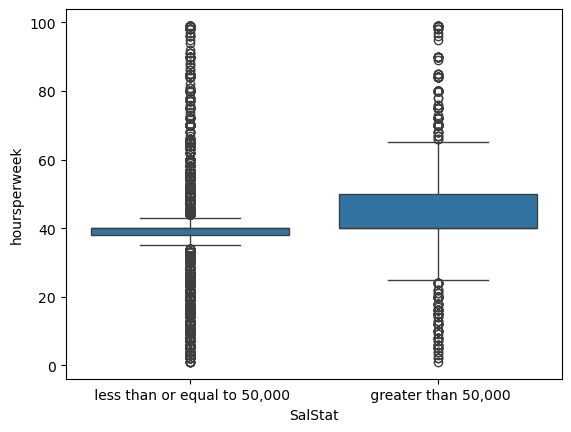

In [48]:
sns.boxplot(x='SalStat', y='hoursperweek', data=data2)
plt.show()

In [51]:
#Insight1: People earning more than 50K tend to work more hours per week compared to those earning less.
#Insight2: High-income individuals show more variability in working hours.